In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('placement.csv')

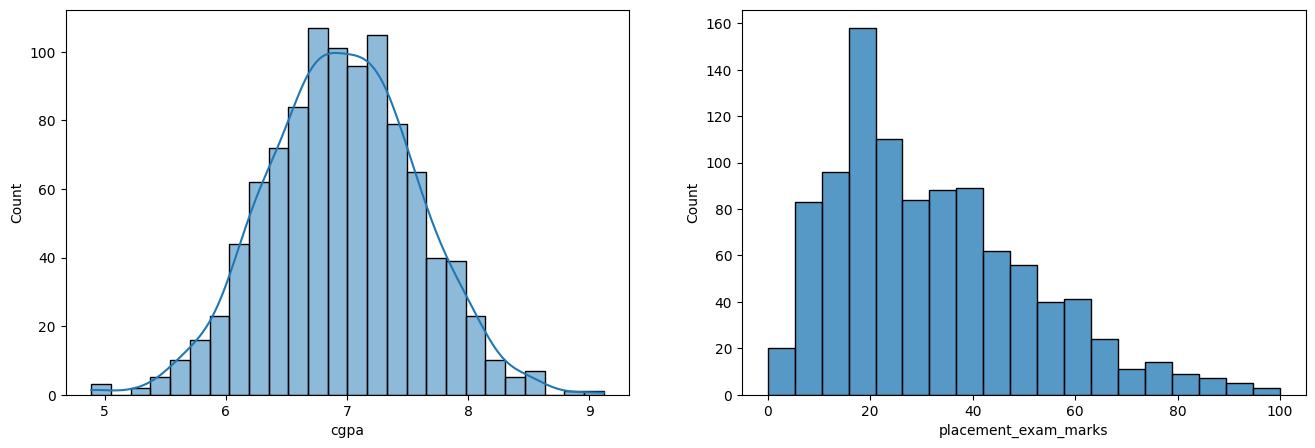

In [3]:
plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['cgpa'], kde=True) # Replaced deprecated distplot [cite: 179, 180]
plt.subplot(1, 2, 2)
sns.histplot(df['placement_exam_marks'])
plt.show()

In [4]:
print(df['placement_exam_marks'].describe())

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64


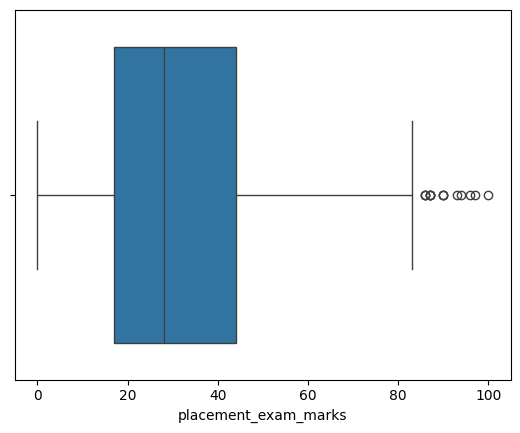

In [5]:
sns.boxplot(x=df['placement_exam_marks'])
plt.show()

In [8]:
Percentile25 = df['placement_exam_marks'].quantile(0.25)
Percentile75 = df['placement_exam_marks'].quantile(0.75)
iqr = Percentile75 - Percentile25

upper_limit = Percentile75 + 1.5 * iqr
lower_limit = Percentile25 - 1.5 * iqr

print(f"Upper Limit: {upper_limit}") 
print(f"Lower Limit: {lower_limit}")

Upper Limit: 84.5
Lower Limit: -23.5


In [9]:
outliers = df[df['placement_exam_marks'] > upper_limit]
print(outliers)

     cgpa  placement_exam_marks  placed
9    7.75                  94.0       1
40   6.60                  86.0       1
61   7.51                  86.0       0
134  6.33                  93.0       0
162  7.80                  90.0       0
283  7.09                  87.0       0
290  8.38                  87.0       0
311  6.97                  87.0       1
324  6.64                  90.0       0
630  6.56                  96.0       1
685  6.05                  87.0       1
730  6.14                  90.0       1
771  7.31                  86.0       1
846  6.99                  97.0       0
917  5.95                 100.0       0


In [11]:
new_df = df[df['placement_exam_marks'] < upper_limit]
print(f"New shape: {new_df.shape}")

New shape: (985, 3)


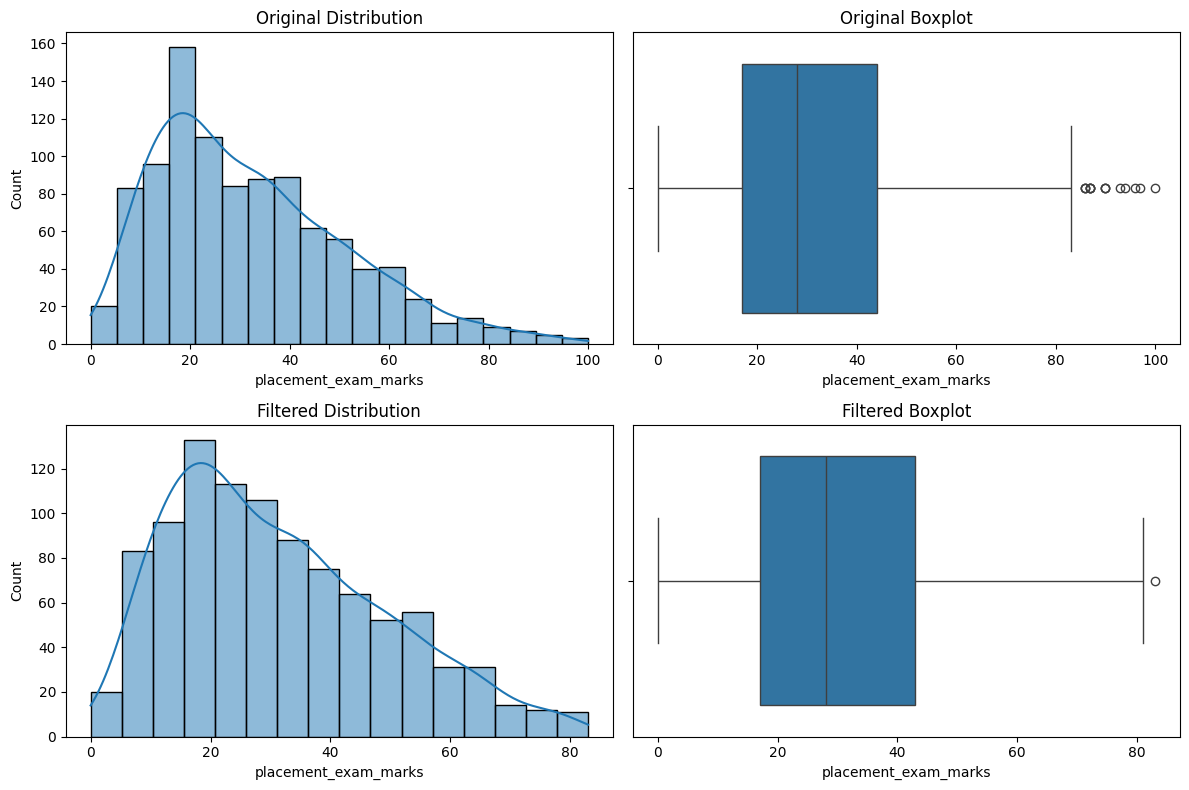

In [12]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title("Original Distribution")

plt.subplot(2, 2, 2)
sns.boxplot(x=df['placement_exam_marks'])
plt.title("Original Boxplot")

plt.subplot(2, 2, 3)
sns.histplot(new_df['placement_exam_marks'], kde=True)
plt.title("Filtered Distribution")

plt.subplot(2, 2, 4)
sns.boxplot(x=new_df['placement_exam_marks'])
plt.title("Filtered Boxplot")

plt.tight_layout()
plt.show()